In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Problem 1

In [3]:
def lcg(x_now, a, b, M):
    return (a * x_now + b) % M


def determine_period(x0, a, b, M):
    seen_values = set()
    x_now  = x0

    while x_now not in seen_values:
        seen_values.add(x_now) 
        x_now  = lcg(x_now, a, b, M)

    return len(seen_values)
    

Ns = [6, 7, 8]
Ks = [3, 7]

x0 = 1


for N in Ns:
    print("")
    M = 2**N
    print(f"----- N = {N}, M = {M} -----")
    for K in Ks:
        print(f"--- K = {K} ---")

        a_tuple_list = [
            (1*K+0,  "K+0  "),
            (1*K+1,  "K+1  "),
            (2*K+1,  "2K+1 "),
            (3*K+1,  "3K+1 "),
            (4*K+1,  "4K+1 "),
            (5*K+1,  "5K+1 "),
            (6*K+1,  "6K+1 "),
            (7*K+1,  "7K+1 "),
            (8*K+1,  "8K+1 "),
            (9*K+1,  "9K+1 "),
            (12*K+1, "12K+1"),
            (16*K+1, "16K+1"),
        ]

        for a_value, a_tag in a_tuple_list:
            p = determine_period(x0=1, a=a_value, b=1, M=M)
            print(f"a = {a_value:<3} = {a_tag} | p = {p:<3} | p/M = {p/M}")


----- N = 6, M = 64 -----
--- K = 3 ---
a = 3   = K+0   | p = 32  | p/M = 0.5
a = 4   = K+1   | p = 3   | p/M = 0.046875
a = 7   = 2K+1  | p = 16  | p/M = 0.25
a = 10  = 3K+1  | p = 6   | p/M = 0.09375
a = 13  = 4K+1  | p = 64  | p/M = 1.0
a = 16  = 5K+1  | p = 2   | p/M = 0.03125
a = 19  = 6K+1  | p = 32  | p/M = 0.5
a = 22  = 7K+1  | p = 6   | p/M = 0.09375
a = 25  = 8K+1  | p = 64  | p/M = 1.0
a = 28  = 9K+1  | p = 3   | p/M = 0.046875
a = 37  = 12K+1 | p = 64  | p/M = 1.0
a = 49  = 16K+1 | p = 64  | p/M = 1.0
--- K = 7 ---
a = 7   = K+0   | p = 16  | p/M = 0.25
a = 8   = K+1   | p = 2   | p/M = 0.03125
a = 15  = 2K+1  | p = 8   | p/M = 0.125
a = 22  = 3K+1  | p = 6   | p/M = 0.09375
a = 29  = 4K+1  | p = 64  | p/M = 1.0
a = 36  = 5K+1  | p = 3   | p/M = 0.046875
a = 43  = 6K+1  | p = 32  | p/M = 0.5
a = 50  = 7K+1  | p = 6   | p/M = 0.09375
a = 57  = 8K+1  | p = 64  | p/M = 1.0
a = 64  = 9K+1  | p = 1   | p/M = 0.015625
a = 85  = 12K+1 | p = 64  | p/M = 1.0
a = 113 = 16K+1 | p = 6

In [10]:
a = set()
a.add(1)
a.add(2)
print(a)
a.add(1)
print(a)

{1, 2}
{1, 2}


# Problem 2



----- Case a -----
period: 16777216
p/M:    1.0

Chi^2: 1.4305114746093748e-06

Observed Moment: 0.4999999701976776
Expected Moment: 0.5
Moment Residual: 2.9802322387695312e-08


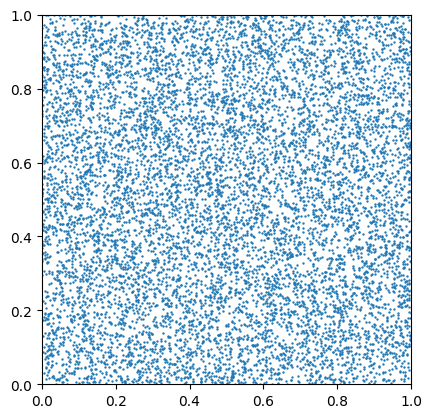



----- Case b -----
period: 16777216
p/M:    1.0

Chi^2: 1.4305114746093748e-06

Observed Moment: 0.4999999701976776
Expected Moment: 0.5
Moment Residual: 2.9802322387695312e-08


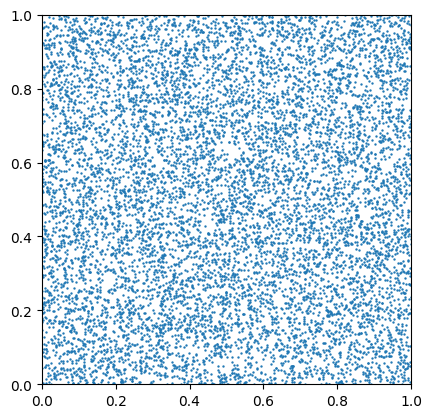



----- Case c -----
period: 16777216
p/M:    1.0

Chi^2: 1.4305114746093748e-06

Observed Moment: 0.4999999701976776
Expected Moment: 0.5
Moment Residual: 2.9802322387695312e-08


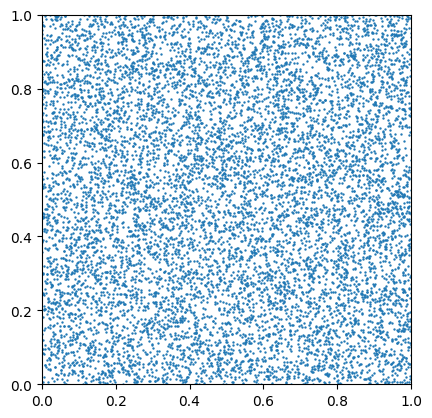



----- Case d -----
period: 4194304
p/M:    0.25

Chi^2: 5.722045898437499e-06

Observed Moment: 0.5000001192092896
Expected Moment: 0.5
Moment Residual: 1.1920928955078125e-07


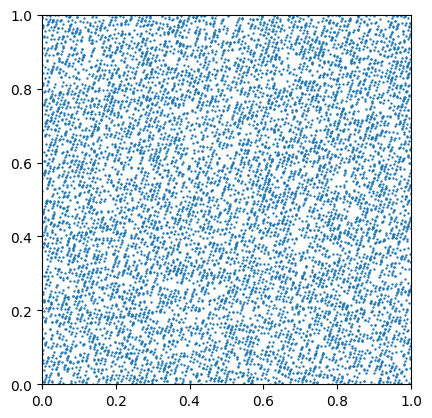



----- Case e -----
period: 4096
p/M:    0.000244140625

Chi^2: 0.005859374999999999

Observed Moment: 0.4998779296875
Expected Moment: 0.5
Moment Residual: 0.0001220703125


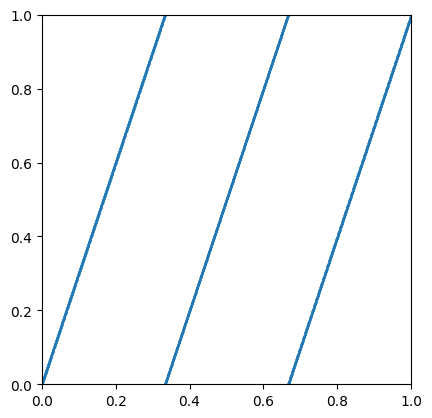



----- Case f -----
period: 4
p/M:    2.384185791015625e-07

Chi^2: 11.000000000000002

Observed Moment: 0.25806351006031036
Expected Moment: 0.5
Moment Residual: 0.24193648993968964


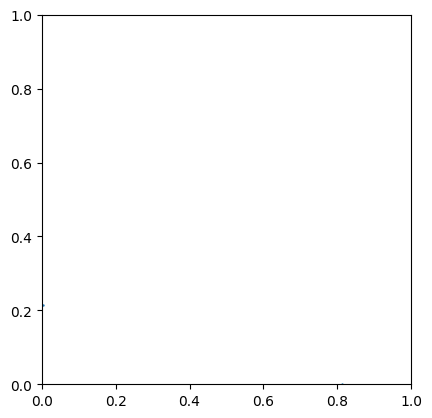

In [4]:
# parameters
M = 2**24

cases = [
    #tag  a           b      x0
    ("a", 1812433253, 1,     69069),
    ("b", 1812433253, 69069, 69069),
    ("c", 69069,      69069, 69069),
    ("d", 65539,      0,     69069),
    ("e", 65539,      0,     1024),
    ("f", 1024,       0,     69069),
]


# functions
def lcg_sequence(x0, a, b, M):
    sequence = []
    seen_values = set()
    x_now  = x0

    while x_now not in seen_values:
        seen_values.add(x_now)
        sequence.append(x_now)
        x_now  = lcg(x_now, a, b, M)

    return sequence


def test_seq_chi2(seq, M):
    observed_counts = np.zeros(10)

    for value in seq:
        leading_digit = int((value / M) * 10)
        observed_counts[leading_digit] += 1

    expected_counts = len(seq) / 10
    diff = observed_counts - expected_counts
    diff_squared = np.array(diff)**2
    chi_is = diff_squared / expected_counts
    chi_squared = np.sum(chi_is)

    return chi_squared


def test_seq_moment(seq, M, k=1):
    etas = np.array(seq) / M

    observed_moment = np.mean(etas**k)
    expected_moment = 1 / (k + 1)

    return observed_moment, expected_moment


def test_seq_serial_plotting(seq, M, save_path="", n_samples=10_000):
    etas = np.array(seq) / M

    xs = np.array(etas[0::2])
    ys = np.array(etas[1::2])

    # sampling because plotting 2**23 points is intractable
    n_samples = min(n_samples, len(xs))
    sample_indices = np.random.choice(len(xs), size=n_samples, replace=False)

    xs_sampled = xs[sample_indices]
    ys_sampled = ys[sample_indices]

    plt.scatter(xs_sampled, ys_sampled, s=0.5)
    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.gca().set_aspect("equal")
    if save_path: plt.savefig(save_path, dpi=600)
    plt.show()


# running cases
for (tag, a, b, x0) in cases:
    sequence = lcg_sequence(x0=x0, a=a, b=b, M=M)
    period = len(sequence)

    print("\n")
    print(f"----- Case {tag} -----")
    
    print(f"period: {len(sequence)}")
    print(f"p/M:    {period/M}")
    print("")

    chi_squared = test_seq_chi2(sequence, M=M)
    print(f"Chi^2: {chi_squared}")
    print("")
    
    observed_moment, expected_moment = test_seq_moment(sequence, M=M)
    print(f"Observed Moment: {observed_moment}")
    print(f"Expected Moment: {expected_moment}")
    print(f"Moment Residual: {abs(observed_moment - expected_moment)}")
    
    #test_seq_serial_plotting(sequence, M=M, save_path=f"hw02q5-case{tag}")
    test_seq_serial_plotting(sequence, M=M)

# Problem 3

In [4]:
# parameters
cases = [
    #tag  a      x0 b  M
    ("a", 65539, 1, 1, 2**24),
    ("b", 66541, 1, 1, 2**24),
    ("c", 16333, 1, 1, 2**24),
]

Sigma = 2.00     # cm^-1
epsilon = 1e-8   # if eta << 1, ln(eta) -> inf, so set eta < epsilon = epsilon 


# functions
sample_r_ffmc = lambda eta: -np.log(eta) / Sigma

for (tag, a, x0, b, M) in cases:
    sequence = lcg_sequence(x0=x0, a=a, b=b, M=M)
    
    etas = np.array(sequence) / M
    etas[etas < epsilon] = epsilon

    distances = sample_r_ffmc(etas)
    mean_free_path = np.mean(distances)

    print(f"Case {tag}: Mean Free Path = {mean_free_path}")

Case a: Mean Free Path = 0.5000008379528935
Case b: Mean Free Path = 0.5000002737038147
Case c: Mean Free Path = 0.5000002737038147
